In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

In [8]:
# Function to plot metrics
def plot_metric(epochs, y_values, ylabel, title):
    plt.figure(figsize=(5, 3))
    plt.plot(epochs, y_values, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.show()

def plot_trainNval_metric(epochs, y_values_val, y_values_test, ylabel, title):
    plt.figure(figsize=(5, 3))
    # if y_values_train is not None:
    #         plt.plot(epochs, y_values_train, marker='o', label="train")

    plt.plot(epochs, y_values_val, marker='o', label="val")
    plt.plot(epochs, y_values_test, marker='o', label="test")
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_confusion_matrix(cm, class_names, title, figsize=(8, 6)):
    """
    Plot confusion matrix with class names
    Args:
        cm: confusion matrix (numpy array)
        class_names: list of class names
        title: plot title
        figsize: figure size
    """
    import seaborn as sns
    
    plt.figure(figsize=figsize)
    
    # Normalize confusion matrix to percentages
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create heatmap
    sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Percentage (%)'})
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Also print raw counts
    print(f"\n{title} - Raw Counts:")
    print(cm)

In [ ]:
def get_metrics_motor(log_file):
    epochs = []
    metrics = {
        'train_loss': [], 
        'val_acc': [], 'val_bacc': [], 'val_kappa': [], 'val_f1': [],
        'test_acc': [], 'test_bacc': [], 'test_kappa': [], 'test_f1': [],
        'learning_rate': [],
        'epoch_time_seconds': [], 'epoch_time_minutes': []
    }

    with open(log_file, 'r', encoding='utf-8') as f:
        logs = json.load(f)
        for line in logs:
            epochs.append(line['epoch'])
            for key in metrics.keys():
                if key in line:
                    metrics[key].append(line[key])
                else:
                    metrics[key].append(None)
    return metrics, epochs

In [ ]:
def get_metrics(log_file):
    epochs = []
    with open(log_file, 'r', encoding='utf-8') as f:
        logs = json.load(f)
        if len(logs) == 0:
            return {}, []
        
        first_line = logs[0]
        metrics = {key: [] for key in first_line.keys() if key != 'epoch'}
    
    with open(log_file, 'r', encoding='utf-8') as f:
        logs = json.load(f)
        for line in logs:
            epochs.append(line['epoch'])
            for key in metrics.keys():
                if key in line:
                    metrics[key].append(line[key])
                else:
                    metrics[key].append(None)
    return metrics, epochs

lr: 5E-4; weight decay: 0.00200; batch size: 256; Best val bacc: 98.84%; 对应的test bacc: 98.77%; best epoch: 33
Training Results Summary

Best Epoch (based on Validation Balanced Accuracy): 33
  Validation Accuracy: 0.9883
  Validation Balanced Accuracy: 0.9884
  Validation Kappa: 0.9860
  Validation F1: 0.9883
  Test Accuracy: 0.9877
  Test Balanced Accuracy: 0.9877
  Test Kappa: 0.9853
  Test F1: 0.9877

[For Comparison Only] Best Test Metrics:
  Best Test Balanced Accuracy: epoch 42, value: 0.9892
  Best Test Kappa: epoch 42, value: 0.9870
  Best Test F1: epoch 42, value: 0.9892


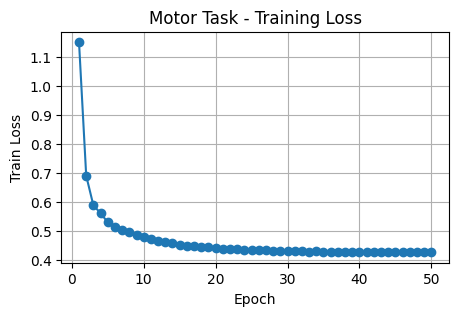

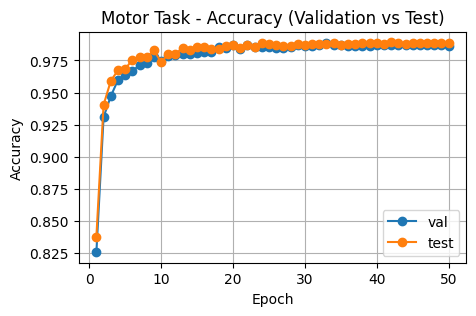

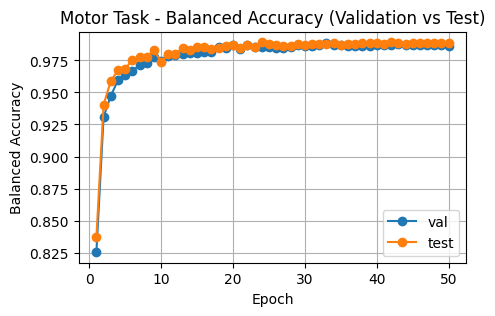

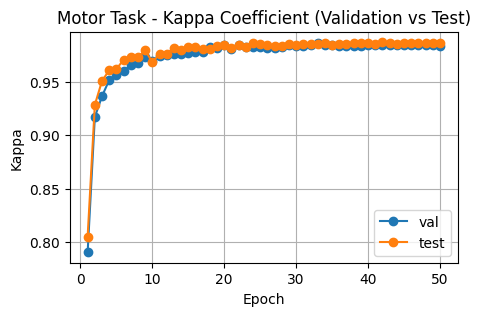

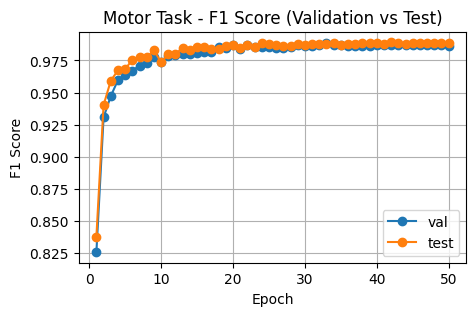

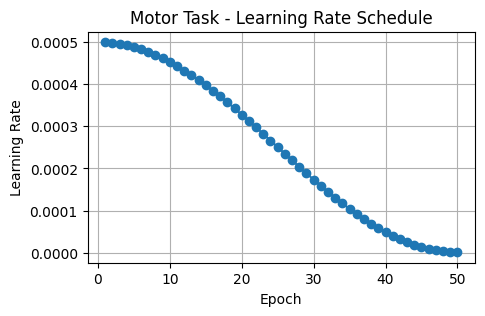


Confusion Matrices (Best Epoch: 33)


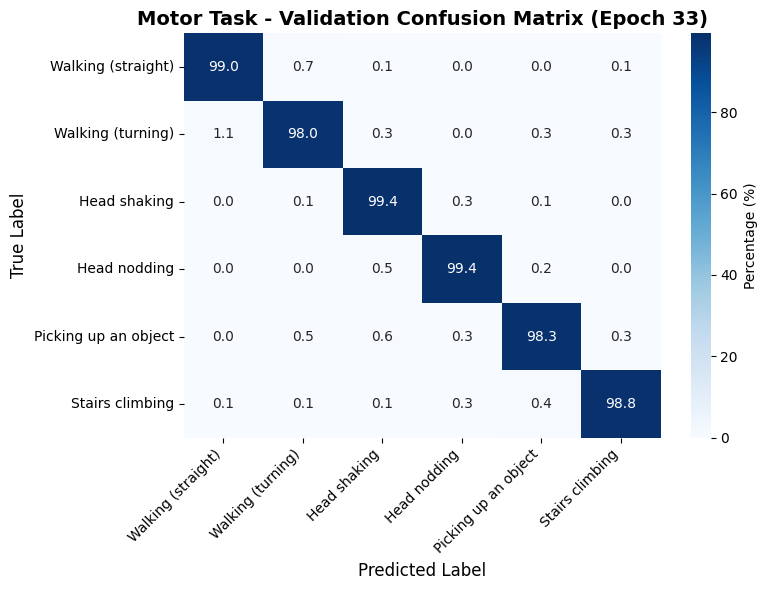


Motor Task - Validation Confusion Matrix (Epoch 33) - Raw Counts:
[[700   5   1   0   0   1]
 [  8 703   2   0   2   2]
 [  0   1 674   2   1   0]
 [  0   0   3 662   1   0]
 [  0   3   4   2 653   2]
 [  1   1   1   2   3 680]]


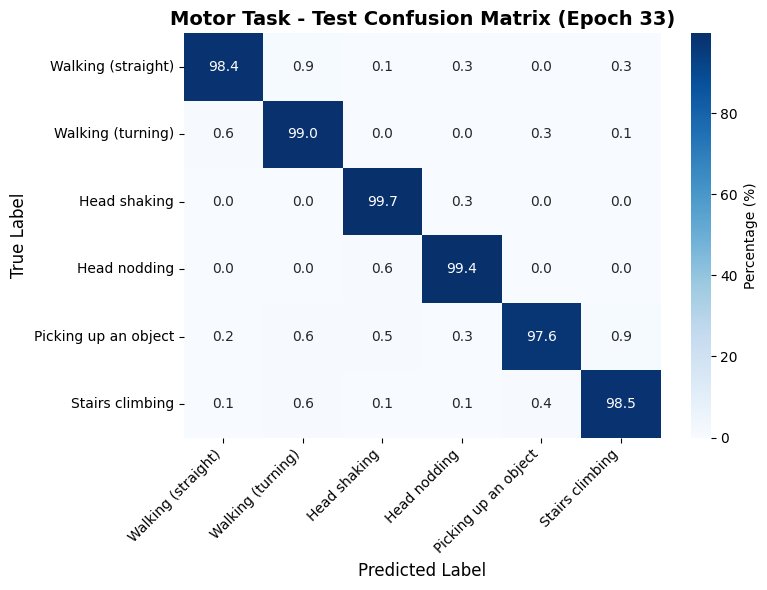


Motor Task - Test Confusion Matrix (Epoch 33) - Raw Counts:
[[691   6   1   2   0   2]
 [  4 695   0   0   2   1]
 [  0   0 676   2   0   0]
 [  0   0   4 646   0   0]
 [  1   4   3   2 650   6]
 [  1   4   1   1   3 665]]


In [ ]:

motor_class_names = [
    'Walking (straight)',
    'Walking (turning)',
    'Head shaking',
    'Head nodding',
    'Picking up an object',
    'Stairs climbing'
]

log_file = './models_weights/MotorTask/exp_author_config-all_patch_reps-all/training_logs.json'
summary_file = './models_weights/MotorTask/exp_author_config-all_patch_reps-all/training_summary.json'
config_file = './models_weights/MotorTask/exp_author_config-all_patch_reps-all/config.yaml'

metrics, epochs = get_metrics_motor(log_file)

# Load config and summary files to get hyperparameters
lr = None
weight_decay = None
batch_size = None

try:
    with open(summary_file, 'r', encoding='utf-8') as f:
        summary = json.load(f)
        lr = summary['training_info'].get('learning_rate')
        batch_size = summary['training_info'].get('batch_size')
except:
    pass

try:
    with open(config_file, 'r', encoding='utf-8') as f:
        config = yaml.safe_load(f)
        if weight_decay is None:
            weight_decay = config.get('weight_decay')
        if lr is None:
            lr = config.get('lr')
        if batch_size is None:
            batch_size = config.get('batch_size')
except:
    pass

# Find best epoch based on Validation Balanced Accuracy
best_epoch_val_bacc = np.argmax(metrics['val_bacc'])
best_val_bacc = metrics['val_bacc'][best_epoch_val_bacc]
best_test_bacc = metrics['test_bacc'][best_epoch_val_bacc]
best_epoch = best_epoch_val_bacc + 1

# Format learning rate (use scientific notation like 5E-05)
if lr is not None:
    # Convert to scientific notation
    if lr < 1:
        # Find the exponent
        exp = int(np.floor(np.log10(lr)))
        coeff = lr / (10 ** exp)
        # Round coefficient to integer if close to integer
        if abs(coeff - round(coeff)) < 0.01:
            coeff = int(round(coeff))
        else:
            coeff = round(coeff, 1)
        lr_str = f"{coeff}E{exp:02d}"
    else:
        lr_str = f"{lr:.5f}"
else:
    lr_str = ""

# Format weight decay (use scientific notation if small, otherwise decimal)
if weight_decay is not None:
    if weight_decay < 0.0001:
        # Find the exponent
        exp = int(np.floor(np.log10(weight_decay)))
        coeff = weight_decay / (10 ** exp)
        # Round coefficient to integer if close to integer
        if abs(coeff - round(coeff)) < 0.01:
            coeff = int(round(coeff))
        else:
            coeff = round(coeff, 1)
        wd_str = f"{coeff}E{exp:02d}"
    else:
        wd_str = f"{weight_decay:.5f}"
else:
    wd_str = ""

# Format batch size
if batch_size is not None:
    bs_str = str(batch_size)
else:
    bs_str = ""

# Print formatted output (first line only)
print(f"lr: {lr_str}; weight decay: {wd_str}; batch size: {bs_str}; Best val bacc: {best_val_bacc*100:.2f}%; 对应的test bacc: {best_test_bacc*100:.2f}%; best epoch: {best_epoch}")

# Print best results summary
print("=" * 60)
print("Training Results Summary")
print("=" * 60)

print(f"\nBest Epoch (based on Validation Balanced Accuracy): {best_epoch}")
print(f"  Validation Accuracy: {metrics['val_acc'][best_epoch_val_bacc]:.4f}")
print(f"  Validation Balanced Accuracy: {metrics['val_bacc'][best_epoch_val_bacc]:.4f}")
print(f"  Validation Kappa: {metrics['val_kappa'][best_epoch_val_bacc]:.4f}")
print(f"  Validation F1: {metrics['val_f1'][best_epoch_val_bacc]:.4f}")
print(f"  Test Accuracy: {metrics['test_acc'][best_epoch_val_bacc]:.4f}")
print(f"  Test Balanced Accuracy: {metrics['test_bacc'][best_epoch_val_bacc]:.4f}")
print(f"  Test Kappa: {metrics['test_kappa'][best_epoch_val_bacc]:.4f}")
print(f"  Test F1: {metrics['test_f1'][best_epoch_val_bacc]:.4f}")

# For comparison: show best test metrics (not used for model selection)
best_epoch_test_bacc = np.argmax(metrics['test_bacc'])
best_epoch_test_kappa = np.argmax(metrics['test_kappa'])
best_epoch_test_f1 = np.argmax(metrics['test_f1'])
print(f"\n[For Comparison Only] Best Test Metrics:")
print(f"  Best Test Balanced Accuracy: epoch {best_epoch_test_bacc + 1}, value: {metrics['test_bacc'][best_epoch_test_bacc]:.4f}")
print(f"  Best Test Kappa: epoch {best_epoch_test_kappa + 1}, value: {metrics['test_kappa'][best_epoch_test_kappa]:.4f}")
print(f"  Best Test F1: epoch {best_epoch_test_f1 + 1}, value: {metrics['test_f1'][best_epoch_test_f1]:.4f}")
print("=" * 60)

# Plot training loss
plot_metric(epochs, metrics['train_loss'], 'Train Loss', 'Motor Task - Training Loss')

# Plot accuracy comparison (validation vs test)
plot_trainNval_metric(epochs, metrics['val_acc'], metrics['test_acc'], 'Accuracy', 'Motor Task - Accuracy (Validation vs Test)')

# Plot balanced accuracy comparison
plot_trainNval_metric(epochs, metrics['val_bacc'], metrics['test_bacc'], 'Balanced Accuracy', 'Motor Task - Balanced Accuracy (Validation vs Test)')

# Plot Kappa comparison
plot_trainNval_metric(epochs, metrics['val_kappa'], metrics['test_kappa'], 'Kappa', 'Motor Task - Kappa Coefficient (Validation vs Test)')

# Plot F1 score comparison
plot_trainNval_metric(epochs, metrics['val_f1'], metrics['test_f1'], 'F1 Score', 'Motor Task - F1 Score (Validation vs Test)')

# Plot learning rate changes
plot_metric(epochs, metrics['learning_rate'], 'Learning Rate', 'Motor Task - Learning Rate Schedule')

# Load and plot confusion matrices from training_summary.json
try:
    with open(summary_file, 'r', encoding='utf-8') as f:
        summary = json.load(f)
        best_epoch = summary['final_results']['best_epoch']
        val_cm = np.array(summary['final_results']['val_cm'])
        test_cm = np.array(summary['final_results']['test_cm'])
        
        print(f"\n{'=' * 60}")
        print(f"Confusion Matrices (Best Epoch: {best_epoch})")
        print(f"{'=' * 60}")
        
        # Plot validation confusion matrix
        plot_confusion_matrix(val_cm, motor_class_names, 
                            f'Motor Task - Validation Confusion Matrix (Epoch {best_epoch})')
        
        # Plot test confusion matrix
        plot_confusion_matrix(test_cm, motor_class_names, 
                            f'Motor Task - Test Confusion Matrix (Epoch {best_epoch})')
except FileNotFoundError:
    print(f"\nWarning: {summary_file} not found. Skipping confusion matrix visualization.")
except KeyError as e:
    print(f"\nWarning: Key {e} not found in summary file. Skipping confusion matrix visualization.")
